# 02 - EDA Cho Deepfake Dataset
Phan tich chat luong dataset truoc khi train (class balance, quality, temporal consistency, distribution shift).

## Cell 1 - Load Dataset Stats

In [2]:
# Muc dich: Doc toan bo frame path va tao bang thong ke co ban cua dataset.
import re
import random
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm

sns.set_theme(style='whitegrid', context='notebook')

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'configs').exists() and (PROJECT_ROOT.parent / 'configs').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

# Doi lai neu ban luu output preprocess o duong dan khac.
DATA_ROOT = PROJECT_ROOT / 'processed_faces'

frame_paths = sorted(DATA_ROOT.glob('*/*/*/*_f*.jpg'))
if len(frame_paths) == 0:
    raise RuntimeError(f'Khong tim thay frame nao trong {DATA_ROOT}.')

records = []
for p in frame_paths:
    split = p.parent.parent.parent.name
    label = p.parent.parent.name
    video_id = p.parent.name
    m = re.search(r'_f(\d+)$', p.stem)
    frame_idx = int(m.group(1)) if m else -1
    records.append({
        'path': str(p),
        'split': split,
        'label': label,
        'video_id': video_id,
        'frame_idx': frame_idx,
    })

df = pd.DataFrame(records)
print('Shape:', df.shape)
display(df.head())
print('Label counts:')
display(df['label'].value_counts())


Shape: (68400, 5)


,path,split,label,video_id,frame_idx
0,d:\Study\Code\Python\deepfake_detector\process...,train,Fake,aafezqchru,0
1,d:\Study\Code\Python\deepfake_detector\process...,train,Fake,aafezqchru,1
2,d:\Study\Code\Python\deepfake_detector\process...,train,Fake,aafezqchru,2
3,d:\Study\Code\Python\deepfake_detector\process...,train,Fake,aafezqchru,3
4,d:\Study\Code\Python\deepfake_detector\process...,train,Fake,aafezqchru,4


Label counts:


label
Fake    51940
Real    16460
Name: count, dtype: int64

## Cell 2 - Phan Phoi Class

C:\Users\Heikapu\AppData\Local\Temp\ipykernel_19760\622931634.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='label', order=order, palette='Set2')


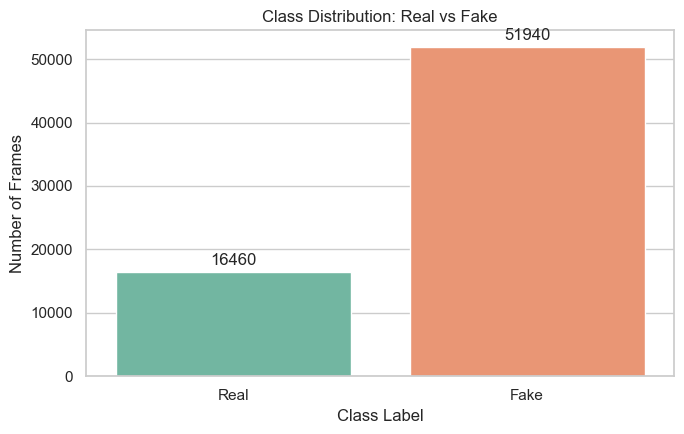

n_real=16460, n_fake=51940, fake/real=3.1555
Goi y pos_weight (Fake la positive): 0.3169
De xuat: dung WeightedRandomSampler + co the ket hop focal/pos_weight.


In [3]:
# Muc dich: Ve class distribution va goi y chien luoc can bang class.
plt.figure(figsize=(7, 4.5))
order = ['Real', 'Fake'] if set(df['label'].unique()) >= {'Real', 'Fake'} else sorted(df['label'].unique())
ax = sns.countplot(data=df, x='label', order=order, palette='Set2')
ax.set_title('Class Distribution: Real vs Fake')
ax.set_xlabel('Class Label')
ax.set_ylabel('Number of Frames')
for c in ax.containers:
    ax.bar_label(c, fmt='%d', padding=3)
plt.tight_layout()
plt.show()

n_real = int((df['label'] == 'Real').sum())
n_fake = int((df['label'] == 'Fake').sum())
imbalance_ratio = (n_fake / n_real) if n_real > 0 else float('inf')
print(f'n_real={n_real}, n_fake={n_fake}, fake/real={imbalance_ratio:.4f}')

if n_fake > 0:
    pos_weight = n_real / n_fake
else:
    pos_weight = float('inf')
print(f'Goi y pos_weight (Fake la positive): {pos_weight:.4f}')

if imbalance_ratio > 1.5 or imbalance_ratio < (1/1.5):
    print('De xuat: dung WeightedRandomSampler + co the ket hop focal/pos_weight.')
else:
    print('Class gan can bang: co the dung shuffle thuong, van theo doi metric AUC/F1.')


## Cell 3 - Kiem Tra Chat Luong Anh

Compute image quality: 100%|██████████| 200/200 [00:01<00:00, 146.26it/s]


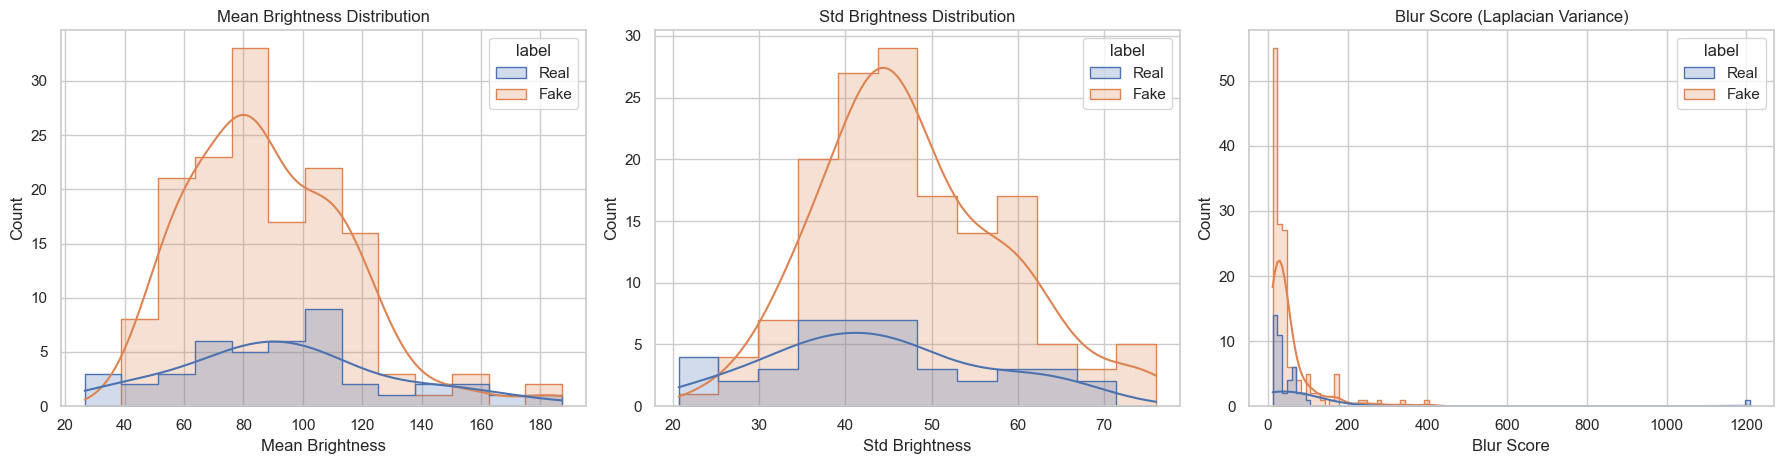

Blur threshold (10th percentile): 15.5467
So anh bi flag blur: 20/192


,path,label,blur_score
32,d:\Study\Code\Python\deepfake_detector\process...,Fake,11.939804
69,d:\Study\Code\Python\deepfake_detector\process...,Fake,12.438899
58,d:\Study\Code\Python\deepfake_detector\process...,Fake,12.460569
0,d:\Study\Code\Python\deepfake_detector\process...,Real,12.674454
118,d:\Study\Code\Python\deepfake_detector\process...,Real,12.703553
82,d:\Study\Code\Python\deepfake_detector\process...,Fake,13.520523
116,d:\Study\Code\Python\deepfake_detector\process...,Real,13.531494
35,d:\Study\Code\Python\deepfake_detector\process...,Fake,13.853224
46,d:\Study\Code\Python\deepfake_detector\process...,Real,13.993414
14,d:\Study\Code\Python\deepfake_detector\process...,Real,14.032806


In [4]:
# Muc dich: Tinh cac metric quality (brightness, std, blur) tren 200 anh ngau nhien.
sample_n = min(200, len(df))
quality_df = df.sample(sample_n, random_state=42).copy().reset_index(drop=True)

mean_brightness = []
std_brightness = []
blur_score = []

for p in tqdm(quality_df['path'], desc='Compute image quality'):
    img_bgr = cv2.imread(p)
    if img_bgr is None:
        mean_brightness.append(np.nan)
        std_brightness.append(np.nan)
        blur_score.append(np.nan)
        continue

    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    mean_brightness.append(float(gray.mean()))
    std_brightness.append(float(gray.std()))
    blur_score.append(float(cv2.Laplacian(gray, cv2.CV_64F).var()))

quality_df['mean_brightness'] = mean_brightness
quality_df['std_brightness'] = std_brightness
quality_df['blur_score'] = blur_score
quality_df = quality_df.dropna().reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
sns.histplot(data=quality_df, x='mean_brightness', hue='label', kde=True, ax=axes[0], element='step', common_norm=False)
axes[0].set_title('Mean Brightness Distribution')
axes[0].set_xlabel('Mean Brightness')
axes[0].set_ylabel('Count')

sns.histplot(data=quality_df, x='std_brightness', hue='label', kde=True, ax=axes[1], element='step', common_norm=False)
axes[1].set_title('Std Brightness Distribution')
axes[1].set_xlabel('Std Brightness')
axes[1].set_ylabel('Count')

sns.histplot(data=quality_df, x='blur_score', hue='label', kde=True, ax=axes[2], element='step', common_norm=False)
axes[2].set_title('Blur Score (Laplacian Variance)')
axes[2].set_xlabel('Blur Score')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

blur_threshold = float(quality_df['blur_score'].quantile(0.10))
blurred_df = quality_df[quality_df['blur_score'] < blur_threshold].copy()
print(f'Blur threshold (10th percentile): {blur_threshold:.4f}')
print(f'So anh bi flag blur: {len(blurred_df)}/{len(quality_df)}')
display(blurred_df[['path', 'label', 'blur_score']].sort_values('blur_score').head(20))


## Cell 4 - Visualize Frames Theo Video

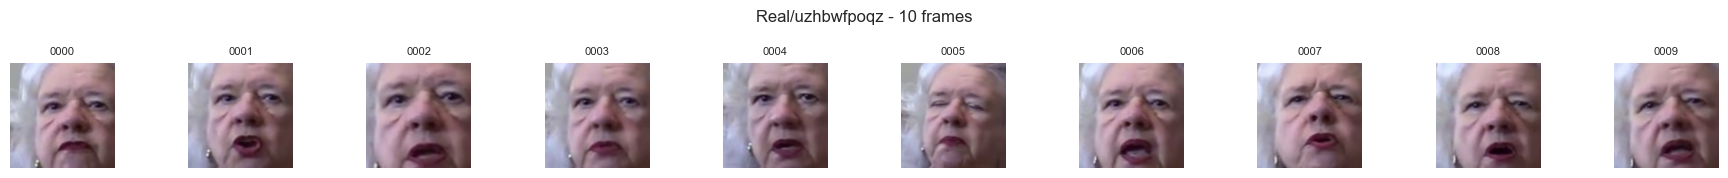

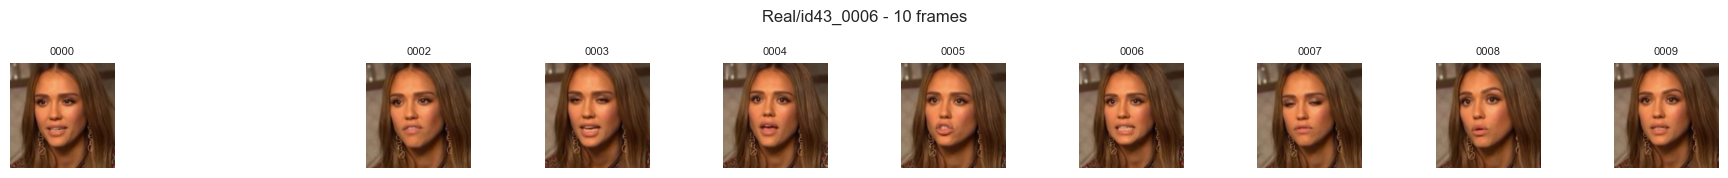

In [5]:
# Muc dich: Chon 3 video Real + 3 video Fake va hien thi toan bo frames theo grid.
_splits = [s for s in ['train', 'val', 'test'] if (DATA_ROOT / s).is_dir()]

real_videos = sorted([
    p
    for s in _splits
    for real_dir in [DATA_ROOT / s / 'Real']
    if real_dir.exists()
    for p in real_dir.iterdir()
    if p.is_dir()
])
fake_videos = sorted([
    p
    for s in _splits
    for fake_dir in [DATA_ROOT / s / 'Fake']
    if fake_dir.exists()
    for p in fake_dir.iterdir()
    if p.is_dir()
])

if len(real_videos) == 0 or len(fake_videos) == 0:
    print('Can co ca video Real va Fake de visualize.')
else:
    picked_real = random.sample(real_videos, min(3, len(real_videos)))
    picked_fake = random.sample(fake_videos, min(3, len(fake_videos)))

    for video_dir in picked_real + picked_fake:
        frame_files = sorted(video_dir.glob('*_f*.jpg'))
        n = len(frame_files)
        if n == 0:
            continue

        cols = min(10, n)
        rows = int(np.ceil(n / cols))
        fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.8, rows * 1.8))
        axes = np.array(axes).reshape(-1)

        for i, ax in enumerate(axes):
            ax.axis('off')
            if i >= n:
                continue
            img_bgr = cv2.imread(str(frame_files[i]))
            if img_bgr is None:
                continue
            ax.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
            ax.set_title(frame_files[i].stem.split('_f')[-1], fontsize=8)

        fig.suptitle(f'{video_dir.parent.name}/{video_dir.name} - {n} frames', fontsize=12)
        plt.tight_layout()
        plt.show()


## Cell 5 - Kiem Tra Temporal Consistency

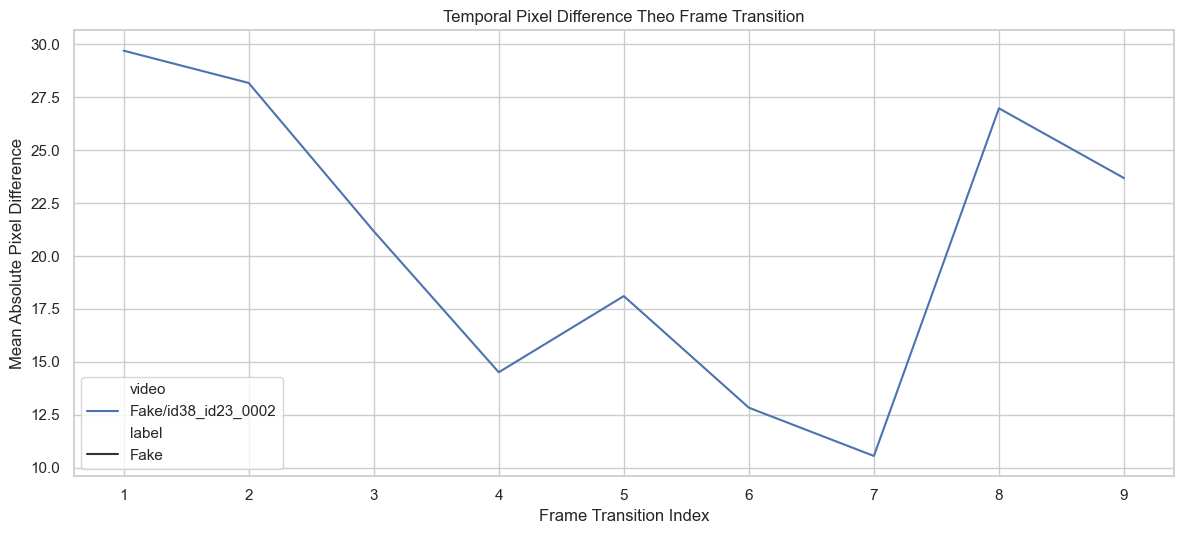

In [6]:
# Muc dich: Tinh pixel difference giua cac frame lien tiep de xem temporal inconsistency.
def temporal_diffs_for_video(video_dir: Path):
    frame_files = sorted(video_dir.glob('*_f*.jpg'))
    if len(frame_files) < 2:
        return []

    diffs = []
    prev = None
    for fp in frame_files:
        img = cv2.imread(str(fp), cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        img = cv2.resize(img, (128, 128), interpolation=cv2.INTER_AREA)
        img = img.astype(np.float32)
        if prev is not None:
            diffs.append(float(np.mean(np.abs(img - prev))))
        prev = img
    return diffs

sample_video_dirs = []
if len(real_videos) > 0:
    sample_video_dirs.extend(random.sample(real_videos, min(3, len(real_videos))))
if len(fake_videos) > 0:
    sample_video_dirs.extend(random.sample(fake_videos, min(3, len(fake_videos))))

diff_records = []
for vd in sample_video_dirs:
    diffs = temporal_diffs_for_video(vd)
    label = vd.parent.name
    key = f'{label}/{vd.name}'
    for i, d in enumerate(diffs, start=1):
        diff_records.append({
            'video': key,
            'label': label,
            'frame_transition': i,
            'pixel_diff': d,
        })

if len(diff_records) == 0:
    print('Khong du du lieu de tinh temporal diff.')
else:
    diff_df = pd.DataFrame(diff_records)
    plt.figure(figsize=(12, 5.5))
    sns.lineplot(data=diff_df, x='frame_transition', y='pixel_diff', hue='video', style='label', markers=False)
    plt.title('Temporal Pixel Difference Theo Frame Transition')
    plt.xlabel('Frame Transition Index')
    plt.ylabel('Mean Absolute Pixel Difference')
    plt.tight_layout()
    plt.show()


## Cell 6 - Distribution Shift Check

Prepare t-SNE features: 100%|██████████| 500/500 [00:03<00:00, 136.56it/s]
C:\Users\Heikapu\AppData\Local\Temp\ipykernel_19760\1176082770.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=tsne_df, x='label', y='pixel_mean', ax=axes[0], palette='Set2')
C:\Users\Heikapu\AppData\Local\Temp\ipykernel_19760\1176082770.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=tsne_df, x='label', y='pixel_std', ax=axes[1], palette='Set2')


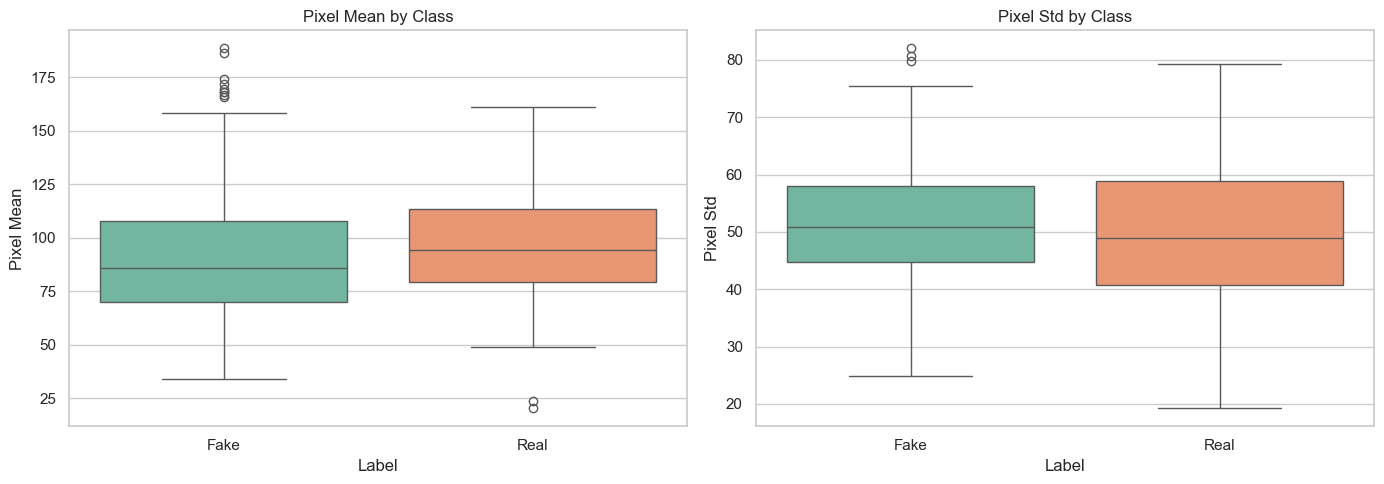

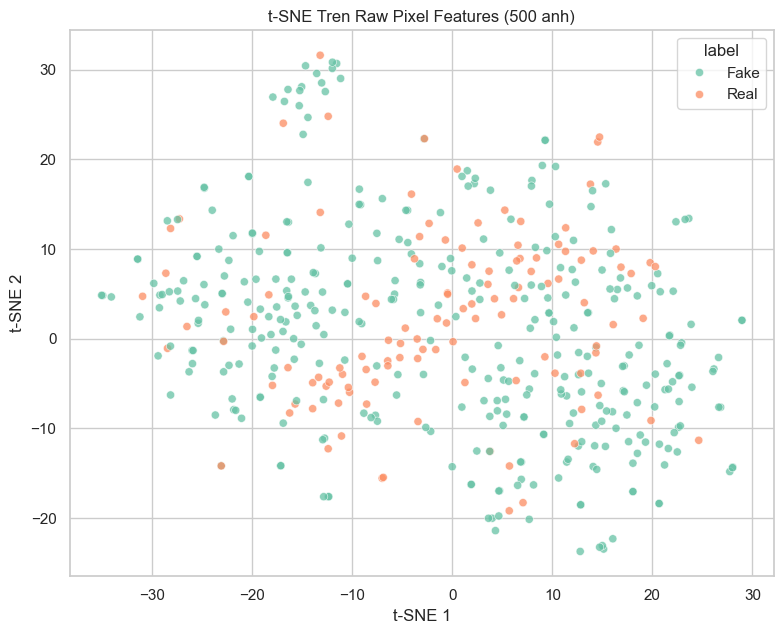

In [7]:
# Muc dich: So sanh mean/std pixel values Real vs Fake va ve t-SNE tren 500 anh.
tsne_n = min(500, len(df))
tsne_df = df.sample(tsne_n, random_state=123).copy().reset_index(drop=True)

pixel_means = []
pixel_stds = []
flat_features = []
valid_indices = []

for idx, p in enumerate(tqdm(tsne_df['path'], desc='Prepare t-SNE features')):
    img_bgr = cv2.imread(p)
    if img_bgr is None:
        continue

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    pixel_means.append(float(img_rgb.mean()))
    pixel_stds.append(float(img_rgb.std()))

    # Resize nho de giam chieu feature truoc khi flatten cho t-SNE.
    small = cv2.resize(img_rgb, (32, 32), interpolation=cv2.INTER_AREA)
    flat_features.append((small.astype(np.float32) / 255.0).reshape(-1))
    valid_indices.append(idx)

tsne_df = tsne_df.iloc[valid_indices].copy().reset_index(drop=True)
tsne_df['pixel_mean'] = pixel_means
tsne_df['pixel_std'] = pixel_stds
X = np.stack(flat_features, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=tsne_df, x='label', y='pixel_mean', ax=axes[0], palette='Set2')
axes[0].set_title('Pixel Mean by Class')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Pixel Mean')

sns.boxplot(data=tsne_df, x='label', y='pixel_std', ax=axes[1], palette='Set2')
axes[1].set_title('Pixel Std by Class')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Pixel Std')
plt.tight_layout()
plt.show()

if len(tsne_df) >= 20:
    X_scaled = StandardScaler().fit_transform(X)
    perplexity = max(5, min(30, len(tsne_df) // 10))
    tsne = TSNE(
        n_components=2,
        random_state=42,
        init='pca',
        learning_rate='auto',
        perplexity=perplexity,
    )
    emb = tsne.fit_transform(X_scaled)
    tsne_plot_df = pd.DataFrame({
        'tsne_1': emb[:, 0],
        'tsne_2': emb[:, 1],
        'label': tsne_df['label'].values,
    })

    plt.figure(figsize=(8, 6.5))
    sns.scatterplot(data=tsne_plot_df, x='tsne_1', y='tsne_2', hue='label', alpha=0.75, s=35, palette='Set2')
    plt.title('t-SNE Tren Raw Pixel Features (500 anh)')
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.tight_layout()
    plt.show()
else:
    print('Khong du mau de ve t-SNE (can it nhat ~20 anh hop le).')
